# E-Commerce Shipping & Delivery Performance Analysis

**Objective:** Identify where and why shipments are getting delayed across warehouses,
carriers, and shipping modes — and recommend fixes to improve on-time delivery rate.

**Dataset:** 50,000 orders | 30 columns | includes order dates, promised vs actual
delivery timelines, warehouse locations, carriers, shipping modes, product info,
and return reasons.

**Business Question:** Which warehouse-carrier-shipping mode combinations are causing
the most delivery delays, and what can operations do about it?

## 1. Import & Setup
In this section, we load the required Python libraries, configure our global notebook display settings, ingest the raw dataset, and inspect its initial shape, column types, and structural health.

In [1]:
# Core libraries for data handling and analysis
import numpy as np 
import pandas as pd

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# For keeping the size of chart consistent
plt.rcParams['figure.figsize']=(10,6)

# Show all columns while previewing data (Useful as we have 30 columns)
pd.set_option('display.max_columns',None)
 

## 2. Load Data & First Look

In [2]:
# Load the Dataset
df_shipping = pd.read_csv('../Raw/E-commerce_Delivery_Shipping_Data_Raw.csv')

# Check the dimensions (rows,columns)
df_shipping.shape

(50000, 30)

In [3]:
## Preview the first few rows to understand the structure & column types
df_shipping.head()


,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,order_value_usd,shipping_method,carrier,distance_km,promised_delivery_days,actual_delivery_days,delivery_status,late_delivery,delivery_delay_days,shipping_cost_usd,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
0,ORD-000001,2026-11-15,CUS-002353,Small Business,Tokyo,Japan,WH-004,Toronto,Home & Kitchen,8.23,10.39,International,EagleCourier,1579.5,11,16,Delivered,Yes,5,133.10,Large,Digital Wallet,Normal,Snow,3,Yes,Late Delivery,2,25.1,Delivered
1,ORD-000002,2026-04-08,CUS-003258,Consumer,Vancouver,Canada,WH-007,Paris,Beauty,0.10,117.69,Standard,BlueRoute,1049.0,5,5,Delivered,No,0,26.95,Small,Debit Card,Normal,Cloudy,5,No,NaN,1,25.9,Delivered
2,ORD-000003,2026-01-05,CUS-001221,Consumer,Houston,United States,WH-005,London,Home & Kitchen,5.51,335.23,International,SpeedyCargo,4552.6,12,16,Delivered,Yes,4,338.62,Large,Debit Card,Low,Snow,4,Yes,Product Defect,1,31.5,Delivered
3,ORD-000004,2026-05-29,CUS-001717,Small Business,Delhi,India,WH-002,Los Angeles,Grocery,3.75,10.57,Standard,ParcelPro,7074.9,8,11,In Transit,Yes,3,270.45,Large,Debit Card,Normal,Snow,3,No,NaN,1,12.6,In Transit
4,ORD-000005,2026-02-22,CUS-000716,Small Business,Nagoya,Japan,WH-006,Berlin,Beauty,0.10,31.37,Economy,GlobalExpress,522.0,8,12,Delivered,Yes,4,12.90,Small,Credit Card,Normal,Storm,2,No,NaN,1,24.9,Delivered


In [4]:
# inspect datatypes, non-null count, memory usage of columns
df_shipping.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    50000 non-null  str    
 1   order_date                  50000 non-null  str    
 2   customer_id                 50000 non-null  str    
 3   customer_segment            50000 non-null  str    
 4   customer_city               50000 non-null  str    
 5   customer_country            50000 non-null  str    
 6   warehouse_id                50000 non-null  str    
 7   warehouse_city              50000 non-null  str    
 8   product_category            50000 non-null  str    
 9   product_weight_kg           50000 non-null  float64
 10  order_value_usd             50000 non-null  float64
 11  shipping_method             50000 non-null  str    
 12  carrier                     50000 non-null  str    
 13  distance_km                 50000 non-null

In [5]:
# check the count of missing (null) values per column
df_shipping.isnull().sum()

order_id                          0
order_date                        0
customer_id                       0
customer_segment                  0
customer_city                     0
customer_country                  0
warehouse_id                      0
warehouse_city                    0
product_category                  0
product_weight_kg                 0
order_value_usd                   0
shipping_method                   0
carrier                           0
distance_km                       0
promised_delivery_days            0
actual_delivery_days              0
delivery_status                   0
late_delivery                     0
delivery_delay_days               0
shipping_cost_usd                 0
package_size                      0
payment_method                    0
order_priority                    0
weather_condition                 0
customer_rating                   0
return_requested                  0
return_reason                 41375
delivery_attempts           

In [6]:
# Generate statistical summary of numerical columns
df_shipping.describe()

,product_weight_kg,order_value_usd,distance_km,promised_delivery_days,actual_delivery_days,delivery_delay_days,shipping_cost_usd,customer_rating,delivery_attempts,warehouse_processing_hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.255028,177.917107,2496.778802,7.197700,8.345940,1.281080,120.515538,3.371840,1.169860,14.412430
std,3.694952,291.600047,1774.633152,3.680229,4.644353,1.679527,108.680030,0.998777,0.390756,9.924904
min,0.100000,10.000000,40.000000,0.000000,0.000000,0.000000,4.050000,1.000000,1.000000,1.000000
25%,0.320000,28.720000,1086.775000,4.000000,5.000000,0.000000,40.640000,3.000000,1.000000,6.600000
50%,0.930000,76.840000,2182.800000,6.000000,8.000000,1.000000,82.970000,3.000000,1.000000,11.900000
75%,2.610000,173.162500,3592.475000,11.000000,12.000000,2.000000,167.422500,4.000000,1.000000,20.700000
max,52.190000,3530.730000,9553.600000,15.000000,27.000000,13.000000,500.000000,5.000000,3.000000,48.000000


### Initial Observations
- Dataset has 50000 rows & 30 Columns, no duplicate structural issues so far
- 'Return_Reason' has larger number of null values - This is expected as only returned orders have return reasons.
- 'Order_Date' is currently stored as text - Need to convert into data_time format

## 3. Data Cleaning

### Fixing data types

In [7]:
# Converting 'order_date' column from str to actual datetime type
df_shipping['order_date']= pd.to_datetime(df_shipping['order_date'],format = '%Y-%m-%d', errors='coerce')

# Confirming and checking if any dates failed to parse
df_shipping['order_date'].dtype , df_shipping['order_date'].isnull().sum()

(dtype('<M8[us]'), np.int64(0))

### Handling duplicates

In [8]:
# Check for duplicate rows
df_shipping.duplicated().sum()

np.int64(0)

In [9]:
df_shipping = df_shipping.drop_duplicates()
print(f"Shape after removing duplicates: {df_shipping.shape}")

Shape after removing duplicates: (50000, 30)


In [10]:
# Final confirmation: no unexpected missing values remain after cleaning
df_shipping.isnull().sum().sum()

np.int64(41375)

### Handling missing values

In [11]:
# Return reason is missing for non returned values - This is expected,not an error
# labeling the nan values clearly as 'Not-return'

df_shipping['return_reason'] = df_shipping['return_reason'].fillna('Not returned')

In [12]:
# Check if more null values are present or not 
df_shipping['return_reason'].isnull().sum()

np.int64(0)

### Note on Missing Data
'return_reason' is a *structural* NaN - it is missing because the order was never returned, not because data was lost. I filled them with "Not returned" rather than dropping rows, since dropping would remove the majority of valid orders.

## 4. Feature Engineering

In [13]:
# Extracting month and day-of-week for seasonal or weekly pattern analysis
df_shipping['order_day'] = df_shipping['order_date'].dt.day_name()
df_shipping['order_month'] = df_shipping['order_date'].dt.month

# Quick check 
df_shipping[['order_date','order_day', 'order_month']].head()


,order_date,order_day,order_month
0,2026-11-15,Sunday,11
1,2026-04-08,Wednesday,4
2,2026-01-05,Monday,1
3,2026-05-29,Friday,5
4,2026-02-22,Sunday,2


In [14]:
# finding shipping cost per kg to compare cost efficiency accross carriers & methods
df_shipping['shipping_cost_per_kg'] = df_shipping['shipping_cost_usd'] / df_shipping['product_weight_kg']

# Sanity check - replacing infinite/undefined values into nan (in case weight = 0)
df_shipping['shipping_cost_per_kg']= df_shipping['shipping_cost_per_kg'].replace([np.inf,-np.inf],np.nan)

# checking null values
df_shipping['shipping_cost_per_kg'].isnull().sum()


np.int64(0)

In [15]:
# Since actual_delivery_days and delivery_delay_days already exist,
# validate them instead of recalculating
df_shipping['delivery_variance_days'] = df_shipping['actual_delivery_days'] - df_shipping['promised_delivery_days']

# Compare our calculation with dataset's own delay_days column
mismatch_count = (df_shipping['delivery_variance_days'] != df_shipping['delivery_delay_days']).sum()
print(f"Rows where delivery_delay_days doesn't match actual - promised: {mismatch_count}")

Rows where delivery_delay_days doesn't match actual - promised: 5538


In [16]:
# Check if all the mismatched rows are early deliveries (Negative Values)
mismatch_rows = df_shipping[df_shipping['delivery_variance_days'] != df_shipping['delivery_delay_days']]
(mismatch_rows['delivery_variance_days'] < 0).all()

np.True_

In [17]:
# Floor our calculated delay column at 0, for same convention as dataset's column
df_shipping['delivery_variance_days_floor'] = df_shipping['delivery_variance_days'].clip(lower=0)

# Re-compare
mismatch_count_floored = (df_shipping['delivery_variance_days_floor'] != df_shipping['delivery_delay_days']).sum()

print(f"Mismatches after flooring the negative values at zero : {mismatch_count_floored}")

Mismatches after flooring the negative values at zero : 0


In [18]:
# Validation complete - drop the helper column 'delivery_variance_days_floor'
df_shipping.drop(columns=['delivery_variance_days_floor'],inplace=True)

In [19]:
# Creating a column delivery_varience_days - To find early, on-time or delayed days of delivery

df_shipping['delivery_variance_days'] = df_shipping['actual_delivery_days'] - df_shipping['promised_delivery_days']

# Defining Early, On-time and delayed deliveries
# defining custom function

def get_delivery_performance(variance):
    if variance < 0:
        return 'Early'
    elif variance == 0:
        return 'On-time'
    elif variance > 0:
        return 'Delayed'

# applying function 
df_shipping['delivery_performance'] = df_shipping['delivery_variance_days'].apply(get_delivery_performance)

# Checking null values
df_shipping['delivery_performance'].isnull().sum()


np.int64(0)

### Note on Feature Engineering Approach
This dataset already had pre-computed delivery metrics (`actual_delivery_days`, `delivery_delay_days`, `late_delivery`). Rather than recalculating them from raw dates, I validated them using manual calculations (`actual - promised`) and found 5,536 mismatches—all early deliveries. Flooring my calculation's negative values to 0 (matching the dataset's convention) brought the mismatch count to 0, confirming `delivery_delay_days = max(0, actual - promised)`.

**Why I kept both delay columns:**
* **`delivery_delay_days`** (dataset provided): This measures *lateness only*, flooring early deliveries to 0. Used for late-specific analysis.
* **`delivery_variance_days`** (derived): This preserves negative values, so early values can be distinguished from on-time ones. Also used to build `delivery_performance`.

**Why early deliveries matter for "delay" analysis:** Early delivery isn't free for the business—it can signal inconsistent warehouse prioritization or customer readiness issues (missed delivery windows, redelivery costs). A warehouse that swings between very early and very late has **high variance** in performance, which is often a bigger operational problem than being uniformly a bit slow, since customers can't trust the estimate at all.

## 5. Exploratory Data Analysis

In [20]:
# What % of value were Early, On-time or Delayed?
(df_shipping['delivery_performance'].value_counts(normalize=True) * 100).round(2)

delivery_performance
Delayed    56.32
On-time    32.60
Early      11.08
Name: proportion, dtype: float64

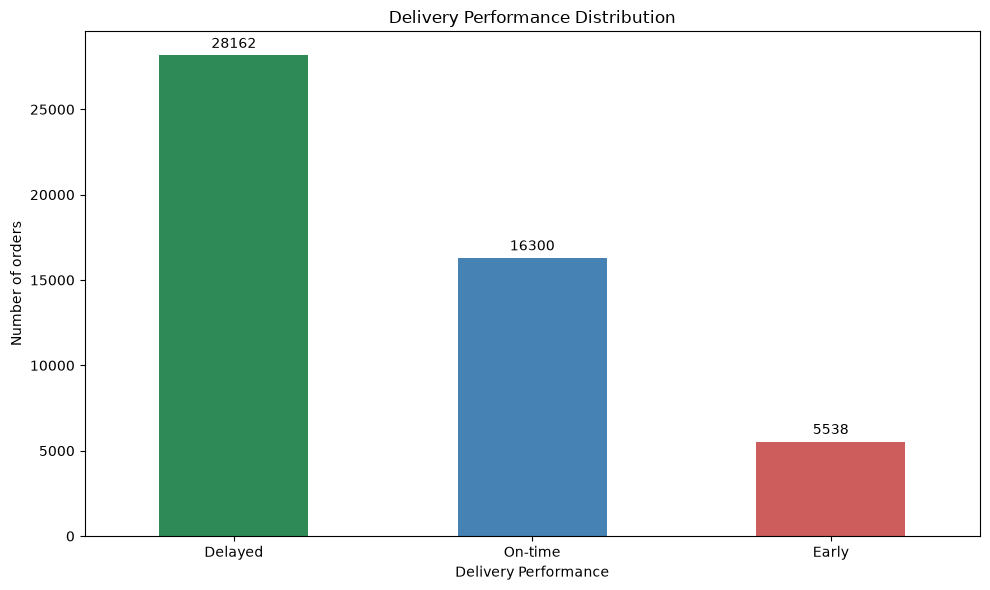

In [21]:
# Visualize the split
dpr = df_shipping['delivery_performance'].value_counts().plot(kind='bar',color= ['seagreen','steelblue','indianred'])
plt.title('Delivery Performance Distribution')
plt.ylabel('Number of orders')
plt.xlabel('Delivery Performance')
plt.xticks(rotation=0)

dpr.bar_label(dpr.containers[0],padding=3)

plt.tight_layout()
plt.show()

**Takeaway:** **56.32%** of orders are delayed, **11.08%** arrive early, and **32.60%** land exactly on time — giving a full baseline before drilling into *where* the delays concentrate.

In [22]:
# Average delay (lateness only) = By warehouse city
warehouse_delay = df_shipping.groupby('warehouse_city')['delivery_delay_days'].mean().sort_values(ascending=False).round(2)
warehouse_delay

warehouse_city
Sydney         1.32
New York       1.31
Paris          1.31
Berlin         1.28
Chicago        1.28
London         1.27
Toronto        1.27
Dubai          1.26
Los Angeles    1.25
Singapore      1.25
Name: delivery_delay_days, dtype: float64

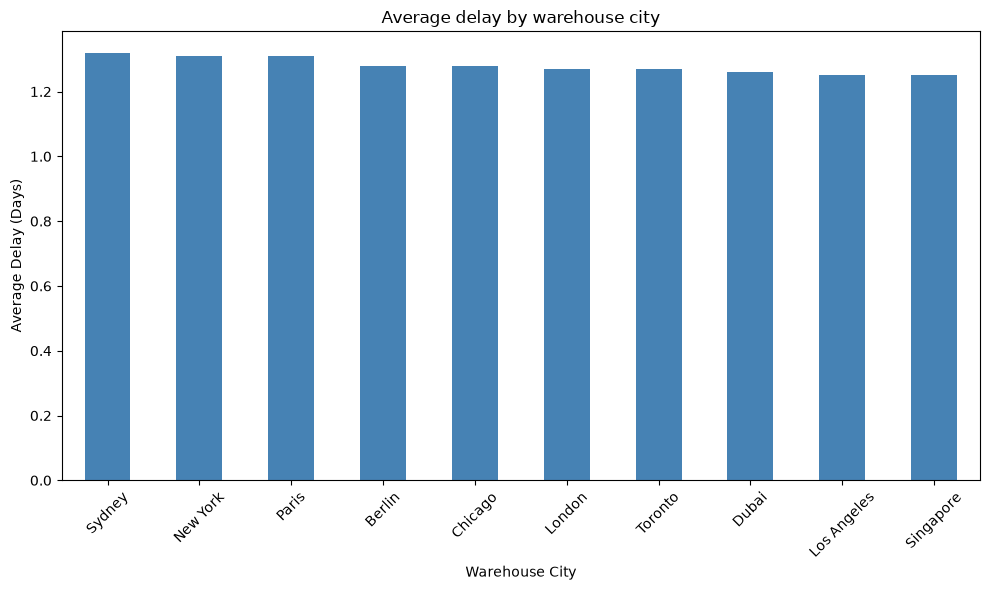

In [23]:
warehouse_delay.plot(kind='bar',color='steelblue')
plt.title('Average delay by warehouse city')
plt.xlabel('Warehouse City')
plt.ylabel('Average Delay (Days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Takeaway:** Warehouse in Sydney has highest average delay of 1.32 days.

In [24]:
df_shipping.groupby('warehouse_city')['delivery_variance_days'].std().sort_values(ascending=False).round(2)

warehouse_city
Berlin         1.85
New York       1.85
Paris          1.85
Sydney         1.85
Singapore      1.82
Chicago        1.82
Dubai          1.82
Toronto        1.79
Los Angeles    1.79
London         1.79
Name: delivery_variance_days, dtype: float64

**Takeaway:** Berlin, New York, Paris, and Sydney share the highest delivery variance (1.85), meaning shipments from these warehouses suffer from the most unpredictable swings rather than being consistently late.

In [25]:
df_shipping['late_delivery'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [26]:
# Identifying bottlenecks by finding which combination of carrier & shipping method has highest late delivery delays
bottlenecks = (
    df_shipping.groupby(['carrier','shipping_method'])['late_delivery']
    .apply(lambda x : (x== 'Yes').mean() * 100)
    .sort_values(ascending=False).round(1)
    )
bottlenecks.head(10)

carrier              shipping_method
GlobalExpress        International      77.6
                     Economy            72.5
PrimeDelivery        International      72.2
BlueRoute            International      72.0
PrimeDelivery        Economy            69.3
FastTrack Logistics  International      68.4
EagleCourier         International      67.1
BlueRoute            Economy            66.7
GlobalExpress        Standard           64.8
SpeedyCargo          International      63.3
Name: late_delivery, dtype: float64

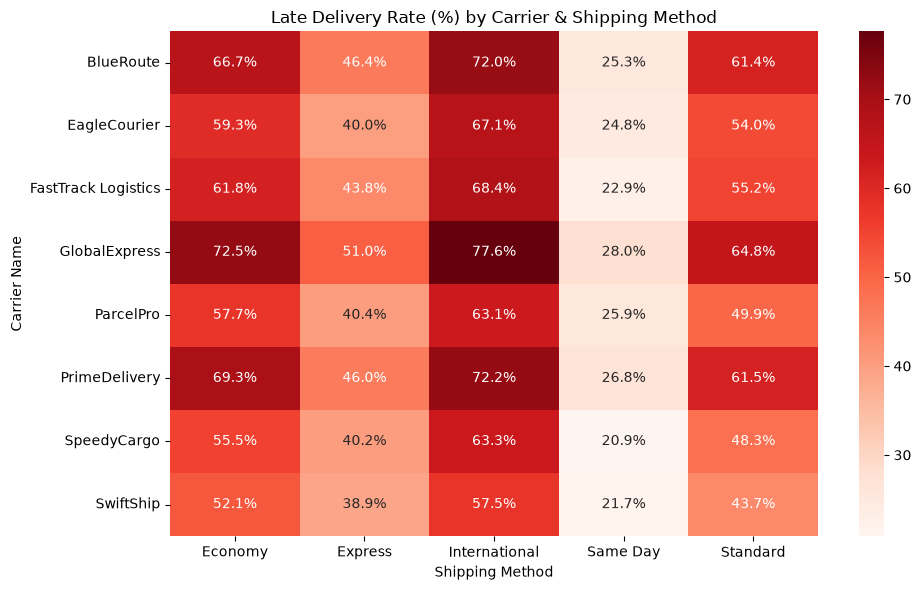

In [27]:
# Visualization

pivot = (
    df_shipping.groupby(['carrier','shipping_method'])['late_delivery']
    .apply(lambda x : (x== 'Yes').mean() * 100)
    .unstack()
)

annot_label = pivot.map(lambda x : f'{x:.1f}%')

sns.heatmap(pivot, annot = annot_label, fmt= '',cmap= 'Reds')
plt.title('Late Delivery Rate (%) by Carrier & Shipping Method')
plt.ylabel('Carrier Name')
plt.xlabel('Shipping Method')
plt.tight_layout()
plt.show()

**Takeaway:** Carrier GlobalExpress using International shipping has the highest late rate at 77.6%.

In [28]:
# Does more time spent in warehouse correlate with delay?
df_shipping.groupby('delivery_performance')['warehouse_processing_hours'].mean()

delivery_performance
Delayed    16.589465
Early       8.841441
On-time    12.543871
Name: warehouse_processing_hours, dtype: float64

**Takeaway:** Delayed orders show noticeably higher warehouse processing time than 
on-time or early orders — suggesting the delay often starts before the package ships.

In [29]:
# Return rate accross Early / On-time / Delayed
df_shipping.groupby('delivery_performance')['return_reason'].apply(lambda x : (x != 'Not returned').mean() * 100 )

delivery_performance
Delayed    23.343513
Early       9.317443
On-time     9.417178
Name: return_reason, dtype: float64

**Takeaway:** Delayed orders are returned at a noticeably higher rate than early or 
on-time orders.

In [30]:
# Average customer rating across delivery attempt

df_shipping.groupby('delivery_attempts')['customer_rating'].mean()

delivery_attempts
1    3.386014
2    3.332153
3    2.417808
Name: customer_rating, dtype: float64

**Takeaway:** Customer rating drops as delivery attempts increase, even for orders 
that are eventually delivered successfully.

In [31]:
# Average customer rating across delivery performance
df_shipping.groupby('delivery_performance')['customer_rating'].mean()

delivery_performance
Delayed    2.725304
Early      4.218852
On-time    4.201104
Name: customer_rating, dtype: float64

**Takeaway:** Customer rating drops when deliveries are delayed (averaging a 2.7 rating), compared to early or on-time deliveries which maintain high ratings above 4.2.

In [32]:
# Delivery performance % across priority of orders.
(df_shipping.groupby('order_priority')['delivery_performance'].value_counts(normalize=True) * 100).round(2)

order_priority  delivery_performance
High            Delayed                 43.71
                On-time                 39.29
                Early                   17.00
Low             Delayed                 81.70
                On-time                 17.65
                Early                    0.64
Normal          Delayed                 63.14
                On-time                 31.29
                Early                    5.57
Urgent          On-time                 40.59
                Early                   33.72
                Delayed                 25.69
Name: proportion, dtype: float64

**Takeaway:** Urgent orders receive priority handling with the lowest delay rate (25.69%), whereas Low and Normal priority orders experience severe delays exceeding 63%.

In [33]:
# Cost Efficiency
df_shipping.groupby('shipping_method')['shipping_cost_per_kg'].mean().sort_values(ascending=False).round(2)

shipping_method
International    463.52
Same Day         317.99
Express          229.96
Standard         162.47
Economy          106.45
Name: shipping_cost_per_kg, dtype: float64

**Takeaway:** International shipping is the most expensive method by a wide margin (averaging 463.52 per kg), while Economy is the cheapest at 106.45 per kg.

## 6. Key Findings

- More than half of all orders — **56.32%** — are delivered late. Only **32.60%** 
  arrive exactly on time, and **11.08%** arrive early. This means late delivery 
  isn't a small problem here, it's actually the most common outcome.

- **Sydney warehouse** has the worst average delay at **1.32 days**. It's not 
  the only issue though — **Berlin, New York, Paris, and Sydney** also show the 
  highest variance (1.85), meaning their delivery times are unpredictable, 
  sometimes early, sometimes very late, rather than being consistently slow.

- The biggest single bottleneck is **GlobalExpress carrier using International 
  shipping**, which has a late rate of **77.6%** — by far the worst combination 
  in the whole dataset.

- Orders that end up delayed also spend more time sitting in the warehouse before 
  they even ship out. This tells us the problem often starts *before* the package 
  leaves the building, not just during transit.

- Delayed orders get returned more often than on-time or early orders — so late 
  delivery isn't just a satisfaction issue, it's actually costing the business 
  through returns too.

- Customer ratings drop sharply when deliveries are late — averaging around 
  **2.7 stars**, compared to **4.2+ stars** for on-time or early deliveries. 
  Ratings also drop the more delivery attempts an order takes, even if it 
  eventually arrives.

- **Order priority matters a lot.** Urgent orders have a much lower delay rate 
  (**25.69%**) compared to Low and Normal priority orders, which are delayed 
  over **63%** of the time. So the priority system is working, but only for 
  urgent orders — everything else is struggling.

- **International shipping is also the most expensive method**, costing around 
  **$463 per kg** on average, compared to just **$106 per kg** for Economy 
  shipping. So it's not just slow — it's also the priciest option, which makes 
  its poor performance even harder to justify.

## 7. Business Recommendations

1. **Review the Sydney warehouse's process first.** It has the worst average 
   delay in the entire network, so this is the single biggest lever to pull 
   to improve overall performance.

2. **Fix the International shipping problem with GlobalExpress.** This one 
   combination has a 77.6% late rate while also being the most expensive 
   method — the business is paying a premium for the worst performance. 
   Either renegotiate the SLA with GlobalExpress, or shift International 
   orders to a different carrier/method where possible.

3. **Look at warehouse processing time, not just shipping time.** Since delays 
   often start before the package even ships, speeding up processing (better 
   staffing, better scheduling) could reduce delays without changing carriers 
   at all.

4. **Extend priority-level handling to more orders.** Urgent orders are clearly 
   handled better (25.69% delay vs 63%+ for others). If the business could 
   afford to treat more orders with the same urgency-level process, delays 
   could drop significantly across the board.

5. **Use delivery consistency, not just average delay, to judge warehouses.** 
   Warehouses like Berlin and Paris aren't always slow — they're unpredictable. 
   That's actually harder for customers to deal with than being reliably a 
   little late, so these warehouses need a different kind of fix: better 
   forecasting and scheduling, not just "work faster."

## 8. Limitations & Next Steps

### Limitations
- The dataset doesn't tell us *why* a specific order was delayed (traffic, 
  staffing shortage, weather, etc.) — we can see the pattern, but not the 
  root cause behind every single delay.
- Customer ratings and return reasons are self-reported by customers, so they 
  might reflect more than just delivery speed (e.g. product quality issues 
  mixed in).
- We're looking at one dataset in time — we don't know if these patterns 
  (like Sydney being slow, or GlobalExpress being unreliable) are getting 
  better or worse over time, since we don't have enough historical data 
  to track trends month over month.

### Next Steps
- Build a simple model that predicts, at the time an order is placed, whether 
  it's likely to be late — so the business can act before the delay happens, 
  not after.
- Bring in cost data for each warehouse and carrier, so any fix (like switching 
  carriers or adding staff) can be weighed against how much it would actually 
  save the business.
- Track these same metrics monthly going forward, to see if the delay problem 
  is improving or getting worse over time.

In [34]:
# Export the cleaned dataset for use in the SQL layer of this project
df_shipping.to_csv('E-commerce_Delivery_Shipping_Data_cleaned.csv', index=False)